# 2D Convection-Diffusion Numerical Simulation Visulization

In this notebook, we will explore and compare the results of the 2D numerical simulazation, and eventually visuliza the results.

In [2]:
# Import
import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
# import the pde solver for a simple 1-d tank of water with a drop of rain
import adv_dif_2D_arr
import adv_dif_2D_arr_Nflux
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar

******************************
context imported. Front of path:
/Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511/EOSC511-TheDeepThinkers
back of path: /Users/qiujunqi/MOAD/tools/SalishSeaTools
******************************

through /Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511/EOSC511-TheDeepThinkers/2D code/Visulization_2D/context.py


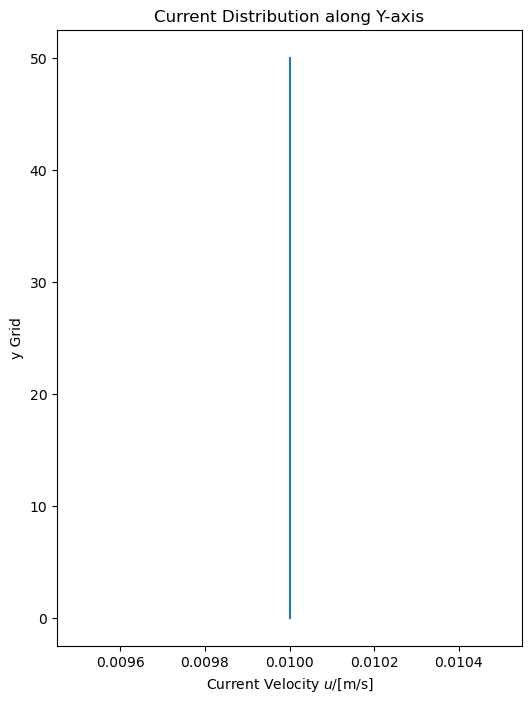

In [50]:
# Run Simulation
#importlib.reload(adv_dif_2D_arr)
importlib.reload(adv_dif_2D_arr_Nflux)

Lx=50
Ly=50
T=1000
n_x = 100
n_y = 100
n_time = 1000
dx = Lx / (n_x-1)
dy = Ly / (n_y-1)
dt = T / (n_time-1)
x = np.linspace(0,Lx,n_x)
y = np.linspace(0,Ly,n_y)
t = np.linspace(0,T,n_time)
#c=adv_dif_2D_arr.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T])
c=adv_dif_2D_arr_Nflux.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T])

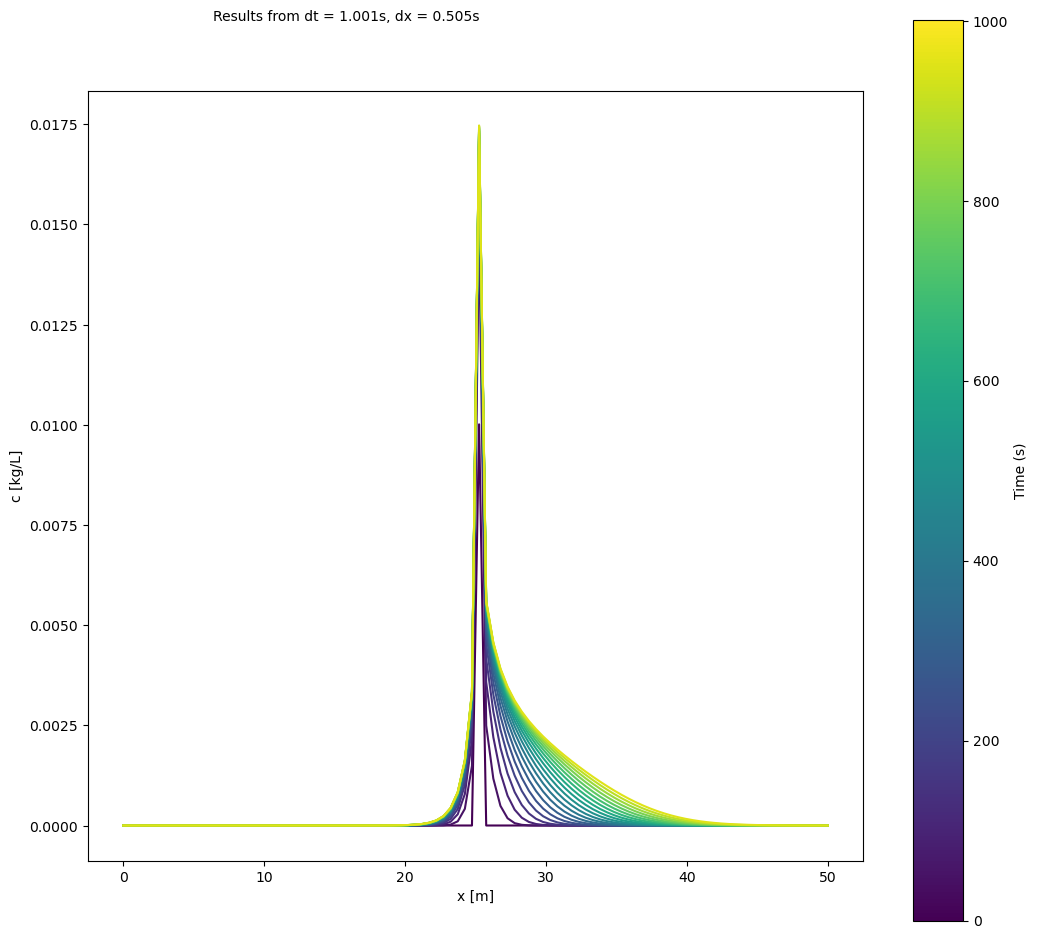

In [51]:
#  
fig, ax_c = plt.subplots(1,1, figsize=(10,10))
the_title = fig.text(0.25, 0.95, 'Results from dt = %.3fs, dx = %.3fs' % (dt, dx))
ax_c.set_ylabel('c [kg/L]')
ax_c.set_xlabel('x [m]')

# We use color to differentiate lines at different times.  Set up the color map
cmap = plt.get_cmap('viridis')
cNorm  = colors.Normalize(vmin=0, vmax=1.*n_time)
cNorm_inseconds = colors.Normalize(vmin=0, vmax=1.*(n_time-1)*dt)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmap)

# Only try to plot 20 lines, so choose an interval if more than that (i.e. plot every interval lines)
interval = int(np.ceil(n_time/20))

# Do the main plot
for time in range(0, n_time, interval):
    colorVal = scalarMap.to_rgba(time)
    ax_c.plot(x,c[:,0,time], color=colorVal)

# Add the custom colorbar
ax_c = fig.add_axes([0.95, 0.05, 0.05, 0.9])
cb1 = colorbar.ColorbarBase(ax_c, cmap=cmap, norm=cNorm_inseconds)
cb1.set_label('Time (s)')

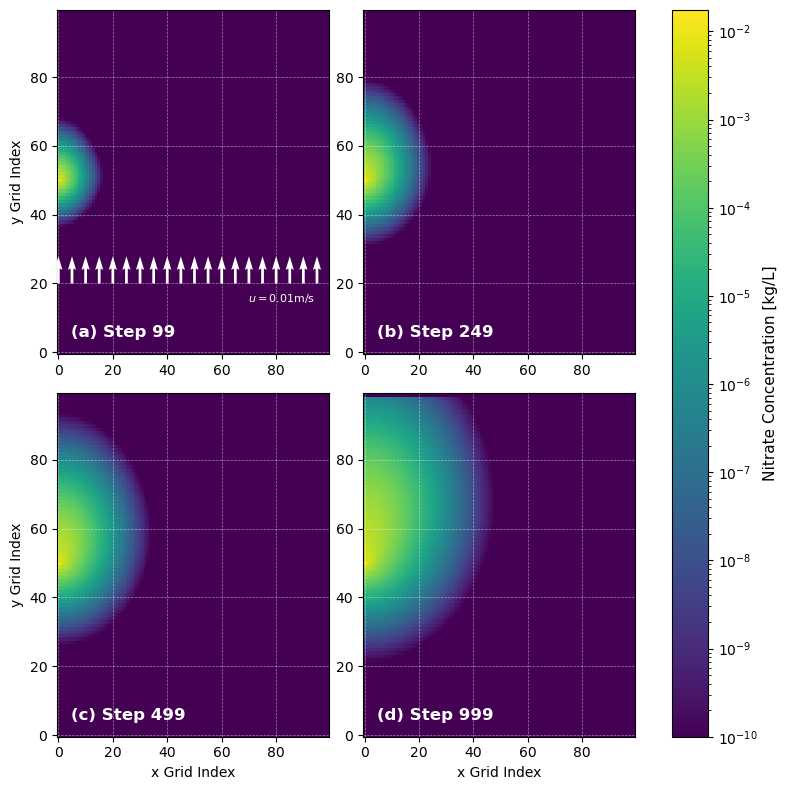

In [52]:
# 2D Visulization

import matplotlib.colors as mcolors

# print(np.shape(c))
# The size would be (100, 100, 1000)

x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)

minval = np.min(c[:,:,:])
maxval = np.max(c[:,:,:])

# print(minval,maxval)

cmap = cmx.viridis
norm = mcolors.LogNorm(vmin=1e-10, vmax=maxval)

fig,axes = plt.subplots(2,2,figsize=(8,8))

tt =[99,249,499,999]
labels = ['(a)', '(b)', '(c)', '(d)']


# cc=cc.swapaxes(0,1)

for ax in axes.flatten():
    t=tt.pop(0)
    cc=c[:,:,t]
    # Prevent 0 by adding a small number
    cc=cc+1e-11
    label=labels.pop(0)

    # Show grid
    # ax.axis('off')
    ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

    im = ax.pcolor(X1, Y1, cc, cmap=cmap, norm=norm, shading='nearest')
    label_full = label + ' Step %d' %t
    ax.text(0.05, 0.05, label_full,  transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')
    
    if label == '(c)' or label =='(d)':
        ax.set_xlabel('x Grid Index')
    if label == '(a)' or label =='(c)':
        ax.set_ylabel('y Grid Index')
        

# Add quiver to represent flow speed
# Arrow position
Y_arrow_position=20
X_arrow=x[::5]
Y_arrow=np.zeros(np.shape(X_arrow))+Y_arrow_position
# Speed distribution
V_speed=np.ones(np.shape(X_arrow)) # The speed is given from fig: Current Distribution
U_speed=np.zeros(np.shape(X_arrow))
# Quiver plot
# The smaller scale is, the bigger arrows are
axes[0,0].quiver(X_arrow, Y_arrow, U_speed, V_speed, color='white', scale=10, width=0.01, zorder=3)

# Add text to demonstrate the current speed
axes[0,0].text(0.7, 0.15, '$u=0.01$m/s',  transform=axes[0,0].transAxes, color='white', fontsize=8)
    

plt.tight_layout()

# Add colorbar
cbar = fig.colorbar(im, ax=axes)
cbar.set_label('Nitrate Concentration [kg/L]', fontsize=11)

plt.show()

With subplots of different time functional, it would be great to start animate the 2D model.

In [ ]:
# Animation
# see link:https://matplotlib.org/stable/gallery/animation/simple_scatter.html for guideline
# to generate gif

import matplotlib.animation as animation
from IPython.display import HTML

fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

# Initial fig: t0

t0=0
cc0=c[:,:,t0]
cc0=cc0+1e-11

im = ax.pcolor(X1, Y1, cc0, cmap=cmap, norm=norm, shading='nearest')
label= ' Step %d' %t0
ax.text(0.05, 0.05, label,  transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Nitrate Concentration [kg/L]', fontsize=11)

# Add arrows
ax.quiver(X_arrow, Y_arrow, U_speed, V_speed, color='white', scale=10, width=0.01, zorder=3)
# Add text to demonstrate the current speed
time_text = ax.text(0.7, 0.15, '$u=0.01$m/s',  transform=ax.transAxes, color='white', fontsize=10)
    
plt.tight_layout()

# Function that renews the plot
def plot_renew(tt):
    cc=c[:,:,tt]+1e-11
    im.set_array(cc.ravel())

    # Renew time label
    time_text.set_text(f' Step {tt}')

    return im, time_text

time_series=range(0,1000,10)
ani = animation.FuncAnimation(fig, plot_renew, frames=time_series, interval=50, blit=True)

plt.close(fig)
HTML(ani.to_jshtml())
# Save animation
ani.save('wave_animation.gif', writer='pillow', fps=20)

When 2D one_time_input is ready, the following section will generate nitrate concentration variation over time.

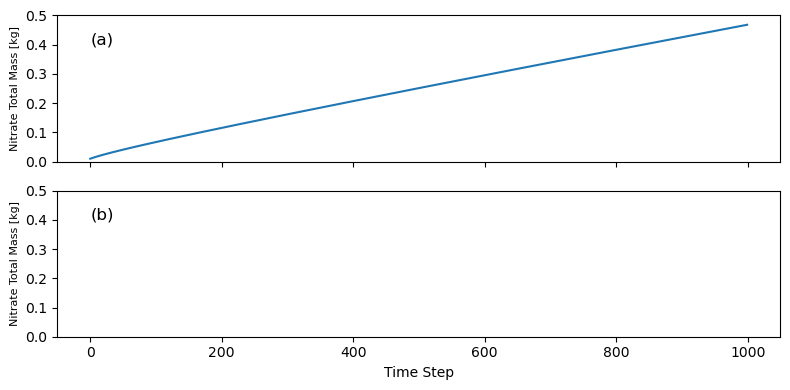

In [88]:
# Total mass over time in the system (to see if it's conserved)
# in so far, we have increasing value of total nitrate only. 
# other sccenerios will be attached as soon as the codes are ready.
total_mass=np.sum(c,axis=(0,1))

fig,axes = plt.subplots(2,1,figsize=(8,4),sharex=True)

# print(np.shape(total_mass))

# total time
time_array=range(1000)

# labels
labels = ['(a)', '(b)', '(c)', '(d)']


axes[0].plot(time_array,total_mass)
axes[0].set_ylim([0,0.5])
# Add labels 
axes[0].set_ylabel('Nitrate Total Mass [kg]',fontsize=8)


axes[1].set_ylabel('Nitrate Total Mass [kg]',fontsize=8)

axes[1].set_xlabel('Time Step')
axes[1].set_ylim([0,0.5])

# Penal
axes[0].text(0.1, 0.4, labels[0], fontsize=12)
axes[1].text(0.1, 0.4, labels[1], fontsize=12)

plt.tight_layout()


plt.show()

## Analytical Solution

Refer to http://rpdata.caltech.edu/courses/aph162/2007/Protocols/diffusion.pdf

The boundary condition will be determined after office hour.